In [3]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/startup_success_dataset.csv")

# Display first 5 rows
print(df.head())

# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print(df.columns)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df['founder_experience_years'] = df['founder_experience_years'].fillna(df['founder_experience_years'].mean())

# Total startups
print("Total Startups:",len(df))

# Funding success percentage
success_rate = (df['outcome'].value_counts(normalize=True) * 100)

print(success_rate)

   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0               4                        13         58            48.225483   
1               1                         6        221            31.532647   
2               3                         5        247             4.969722   
3               3                        14        229             3.084209   
4               1                        17        235            13.818188   

   product_traction_users  burn_rate_million  revenue_million investor_type  \
0                  594843          18.519211     1.483962e+06      tier2_vc   
1                  393020          14.298149     8.620568e+05      tier2_vc   
2                   27636          20.447567     9.726169e+04          none   
3                  235376           8.177417     1.145785e+06          none   
4                  391765           4.879792     8.608949e+05          none   

      sector founder_background      outcome  
0  

In [4]:
# Statistical summary
print(df.describe())

# Mean values
print("Average Team Size:", df['team_size'].mean())

print("Average Founder Experience:", df['founder_experience_years'].mean())

# Median
print("Median Revenue:", df['revenue_million'].median())

# Quartiles
print(df['revenue_million'].quantile([0.25, 0.50, 0.75]))

       funding_rounds  founder_experience_years      team_size  \
count   100000.000000             100000.000000  100000.000000   
mean         2.002300                 12.024300     150.732000   
std          1.414671                  7.208089      86.272631   
min          0.000000                  0.000000       2.000000   
25%          1.000000                  6.000000      76.000000   
50%          2.000000                 12.000000     151.000000   
75%          3.000000                 18.000000     226.000000   
max          8.000000                 24.000000     299.000000   

       market_size_billion  product_traction_users  burn_rate_million  \
count        100000.000000           100000.000000      100000.000000   
mean             33.203875           285422.832730          16.776213   
std              43.034753           159323.885405          15.711368   
min               0.288738              668.000000           0.279763   
25%              10.196778           161

In [5]:
# probability of AI startups getting funded

ai_startups = df[df['sector'] == 'AI']
prob_ai = len(ai_startups[ai_startups['outcome'].isin(['Acquisition', 'IPO'])]) / len(ai_startups)
print("probability AI startups gets funded:", prob_ai)

# Founder experience > 5 years

exp_startups = df[df['founder_experience_years'] > 5]
prob_exp = len(exp_startups[exp_startups['outcome'].isin(['Acquisition', 'IPO'])]) / len(exp_startups)
print("probability experience founder gets funded:", prob_exp)

probability AI startups gets funded: 0.4413812704277391
probability experience founder gets funded: 0.48374673028642035


probability AI startups gets funded: 0.4413812704277391


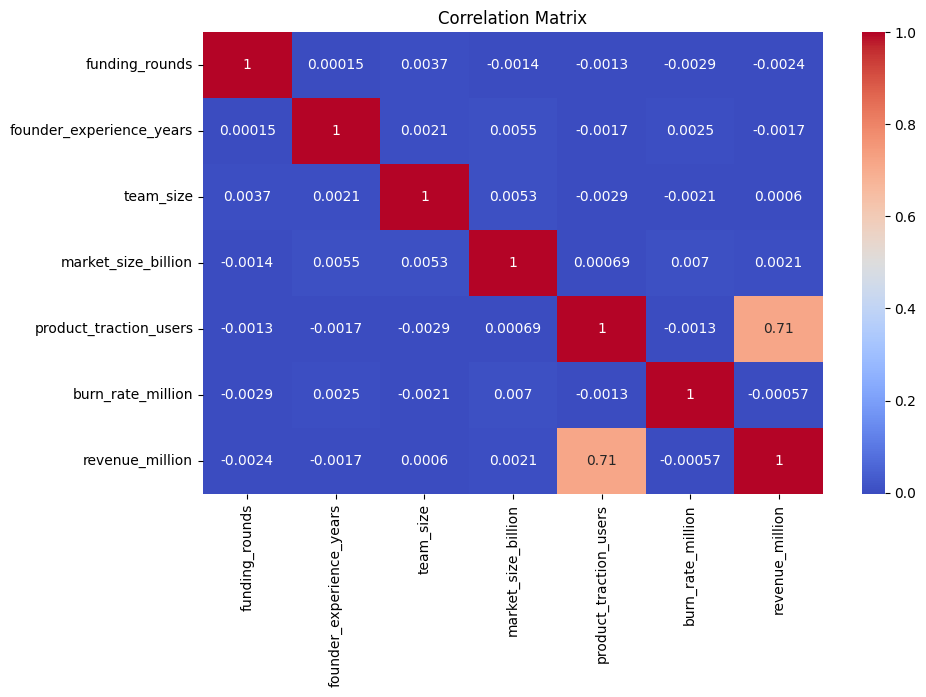

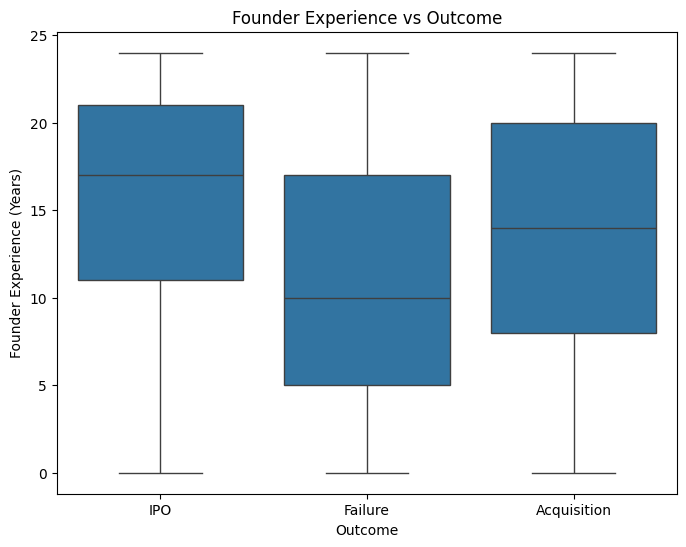

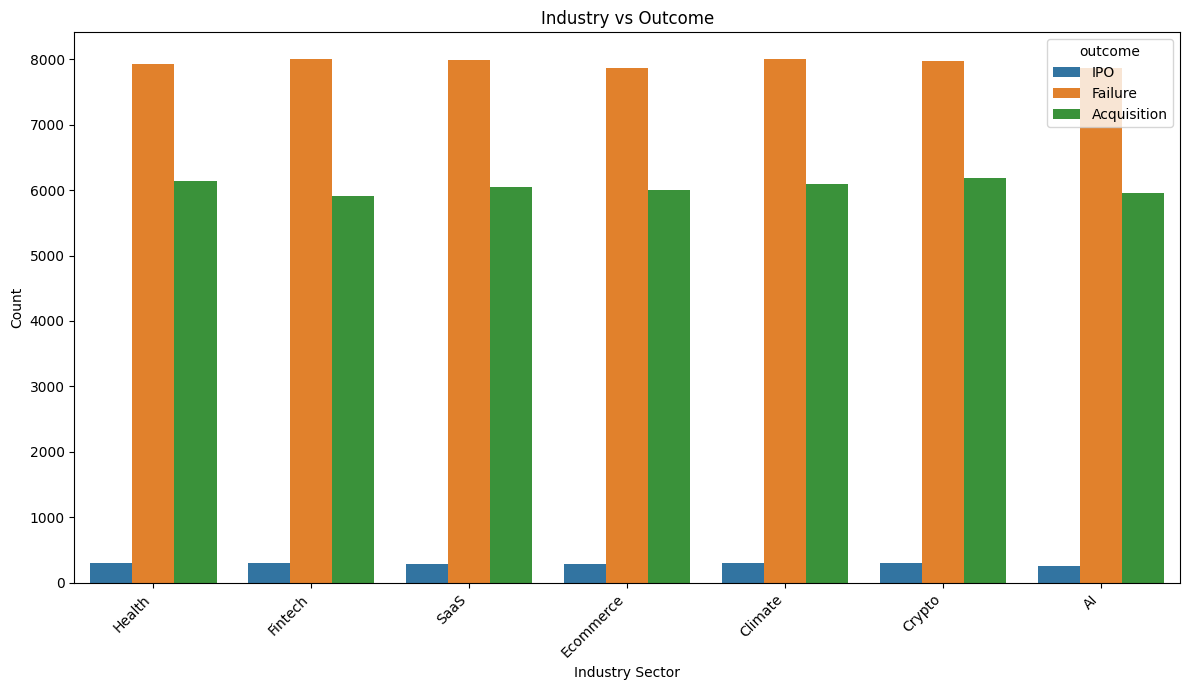

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# probability of AI startups getting funded

ai_startups = df[df['sector'] == 'AI']
prob_ai = len(ai_startups[ai_startups['outcome'].isin(['Acquisition', 'IPO'])]) / len(ai_startups)
print("probability AI startups gets funded:", prob_ai)

# Correlation matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()





# Founder experience > 5 years

plt.figure(figsize=(8, 6))
sns.boxplot(x='outcome', y='founder_experience_years', data=df)
plt.title("Founder Experience vs Outcome")
plt.xlabel("Outcome")
plt.ylabel("Founder Experience (Years)")
plt.show()

# Industry vs Funding

plt.figure(figsize=(12, 7))
sns.countplot(x='sector', hue='outcome', data=df)
plt.xticks(rotation=45, ha='right')
plt.title("Industry vs Outcome")
plt.xlabel("Industry Sector")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import ttest_ind

# Funded startups (Acquisition or IPO)
funded = df[df['outcome'].isin(['Acquisition', 'IPO'])]['founder_experience_years']

# Non-funded startups (Failure)
not_funded = df[df['outcome'] == 'Failure']['founder_experience_years']

# T-Test
t_stat, p_value = ttest_ind(funded, not_funded, equal_var=False) # Use Welch's t-test if variances are not assumed equal

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

#Interpretation

if p_value < 0.05:
    print("Founder experience significantly affects funding success")
else:
    print("Founder experience does not significantly affects funding")

T-Statistic: 64.10652184977621
P-Value: 0.0
Founder experience significantly affects funding success


In [10]:
# High growth startups (Removed as 'Growth_Rate' column does not exist)
# df['segment'] = np.where(df['Growth_Rate'] > 70, 'High Growth', 'Normal Growth')

# Experience founders
df['Founder_Category'] = np.where(df['founder_experience_years'] > 5, 'Experienced', 'Beginner')

# Revenue driven startups
df['Revenue_Category'] = np.where(df['revenue_million'] > 0.5, 'High Revenue', 'Low Revenue') # Adjusted threshold for revenue_million (in millions)

# Create a 'funded' status column based on 'outcome'
df['is_funded'] = df['outcome'].isin(['Acquisition', 'IPO']).astype(int)

# Segment analysis - using 'Founder_Category' and 'Revenue_Category' as 'Growth_Rate' was not available
print("Analysis by Founder Category:")
founder_segment_analysis = df.groupby('Founder_Category')['is_funded'].mean()
print(founder_segment_analysis)
print("\nAnalysis by Revenue Category:")
revenue_segment_analysis = df.groupby('Revenue_Category')['is_funded'].mean()
print(revenue_segment_analysis)

Analysis by Founder Category:
Founder_Category
Beginner       0.317184
Experienced    0.483747
Name: is_funded, dtype: float64

Analysis by Revenue Category:
Revenue_Category
High Revenue    0.4439
Name: is_funded, dtype: float64


In [11]:
# Funding success by industry
industry_success = df.groupby('sector')['is_funded'].mean()
print("Funding success by industry:")
print(industry_success.sort_values(ascending=False))

# 'city' column does not exist in the DataFrame, so this section is removed.
# city_success = df.groupby('city')['is_funded'].mean()
# print(city_success.sort_values(ascending=False))

# Correlation with funding (re-calculating corr to include 'is_funded')
corr_updated = df.corr(numeric_only=True)
print("\nCorrelation with funding (is_funded column):")
print(corr_updated['is_funded'].sort_values(ascending=False))

# Final recommendations
print("\nFinal Recommendations:")
print("Top industries attract more investments.")
print("Experienced founders have higher funding chances.")
print("Investors should focus on scalable startups.")


Funding success by industry:
sector
Crypto       0.449018
Health       0.448422
Climate      0.444629
Ecommerce    0.444232
SaaS         0.442685
AI           0.441381
Fintech      0.436779
Name: is_funded, dtype: float64

Correlation with funding (is_funded column):
is_funded                   1.000000
revenue_million             0.453296
product_traction_users      0.418118
funding_rounds              0.236516
founder_experience_years    0.198618
team_size                   0.094297
burn_rate_million           0.004308
market_size_billion         0.003095
Name: is_funded, dtype: float64

Final Recommendations:
Top industries attract more investments.
Experienced founders have higher funding chances.
Investors should focus on scalable startups.
